# 01 · Exploratory Data Analysis
Loan **default** prediction. Goals here: understand the target, find data-quality issues, test for **leakage**, and check **class imbalance** — the things that decide whether the rest of the project is honest.

In [1]:
# Make `src` importable when running from the notebooks/ folder
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import pandas as pd, numpy as np
pd.set_option('display.max_columns', 60)

In [2]:
from src.data_loader import load_raw, target_distribution
from src.cleaning import missingness_report
raw = load_raw()
print(raw.shape)
raw.head()

(100000, 21)


,Unnamed: 0,loan_id,gender,disbursemet_date,currency,country,sex,is_employed,job,location,loan_amount,number_of_defaults,outstanding_balance,interest_rate,age,number_of_defaults.1,remaining term,salary,marital_status,age.1,Loan Status
0,0,8d05de78-ff32-46b1-aeb5-b3190f9c158a,female,2022 10 29,USD,Zimbabwe,female,True,Teacher,Beitbridge,39000.0,0,48653.011473,0.22,37,0,47,3230.038869,married,37,Did not default
1,1,368bf756-fcf2-4822-9612-f445d90b485b,other,2020 06 06,USD,Zimbabwe,other,True,Teacher,Harare,27000.0,2,28752.062237,0.20,43,2,62,3194.139103,single,43,Did not default
2,2,6e3be39e-49b5-45b5-aab6-c6556de53c6f,other,2023 09 29,USD,Zimbabwe,other,True,Nurse,Gweru,35000.0,1,44797.554126,0.22,43,1,57,3330.826656,married,43,Did not default
3,3,191c62f8-2211-49fe-ba91-43556b307871,female,2022 06 22,USD,Zimbabwe,female,True,Doctor,Rusape,24000.0,0,35681.496413,0.23,47,0,42,2246.797020,divorced,47,Did not default
4,4,477cd8a1-3b01-4623-9318-8cd6122a8346,male,2023 02 08,USD,Zimbabwe,male,True,Nurse,Chipinge,19000.0,0,34156.055882,0.20,42,0,45,2310.858441,married,42,Did not default


## Target distribution & imbalance

Loan Status
Did not default    85134
Defaulted          14866
Name: count, dtype: int64
positive (Defaulted) rate = 14.9%


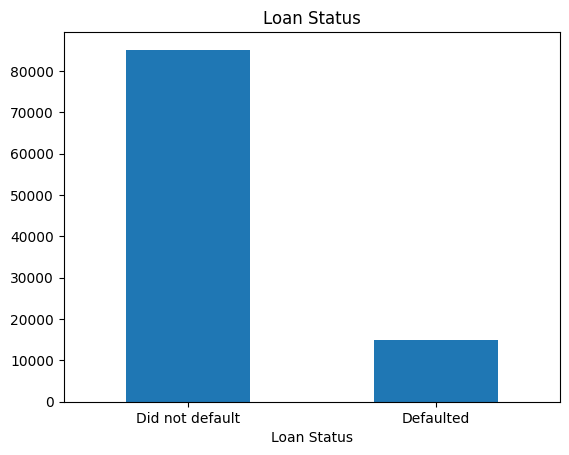

In [3]:
dist = target_distribution(raw)
print(dist)
print('positive (Defaulted) rate = %.1f%%' % (100*dist['Defaulted']/dist.sum()))
dist.plot(kind='bar', title='Loan Status', rot=0);

> ~85/15 split. **Accuracy is a trap** (predicting 'never defaults' scores 85%). We optimise and report F1 / ROC-AUC / PR-AUC instead.

## Data-quality issues

In [4]:
# Duplicate columns (verified identical -> dropped in cleaning)
print('age == age.1 :', (raw['age'].fillna(-1)==raw['age.1'].fillna(-1)).mean())
print('ndef == ndef.1:', (raw['number_of_defaults'].fillna(-1)==raw['number_of_defaults.1'].fillna(-1)).mean())
print('gender == sex :', (raw['gender'].fillna('x')==raw['sex'].fillna('x')).mean())

age == age.1 : 1.0
ndef == ndef.1: 1.0
gender == sex : 1.0


In [5]:
for c in ['currency','country','job','marital_status']:
    print('\n', c, '->'); print(raw[c].value_counts(dropna=False).head(12))
print('\nlocation unique:', raw['location'].nunique())


 currency ->
currency
USD     99980
$USD       20
Name: count, dtype: int64

 country ->
country
Zimbabwe    99787
zimbabwe      100
NaN           100
Zim            13
Name: count, dtype: int64

 job ->
job
Engineer              16524
Nurse                 15284
Data Analyst          13204
Doctor                12186
Software Developer    11932
Teacher                8950
Accountant             7802
NaN                    4136
SoftwareDeveloper      3564
Data Scientist         3521
Lawyer                 2862
Data Scintist            35
Name: count, dtype: int64

 marital_status ->
marital_status
married     44710
divorced    26465
single      25698
             3127
Name: count, dtype: int64

location unique: 157


In [6]:
# remaining term stored as text with stray '_' e.g. '69_'
print(raw['remaining term'].astype(str).str.contains('_').sum(), "values contain '_'")
missingness_report(raw)

1875 values contain '_'


,missing,pct
job,4136,4.14
location,595,0.60
country,100,0.10


## Leakage check (critical)
If a feature secretly *is* the answer, scores look great but collapse in production. Test the suspects: `number_of_defaults` and `outstanding_balance`.

In [7]:
import numpy as np
g = raw.groupby('number_of_defaults')['Loan Status'].apply(lambda s:(s=='Defaulted').mean())
print('default rate by #prior defaults:'); print(g.round(3))
print('\noutstanding_balance by target:')
print(raw.groupby('Loan Status')['outstanding_balance'].mean().round(1))

default rate by #prior defaults:
number_of_defaults
0    0.112
1    0.204
2    0.262
Name: Loan Status, dtype: float64

outstanding_balance by target:
Loan Status
Defaulted          34714.5
Did not default    37357.9
Name: outstanding_balance, dtype: float64


> Default rate rises smoothly with prior defaults (11%→20%→26%) and balances overlap — **legitimate signal, not leakage**. The model must genuinely learn.

## Numeric structure

In [8]:
num = ['loan_amount','outstanding_balance','interest_rate','age','salary']
raw[num].describe().round(2)

,loan_amount,outstanding_balance,interest_rate,age,salary
count,100000.00,100000.00,100000.00,100000.00,100000.00
mean,31120.00,36964.91,0.21,43.57,2781.80
std,15895.09,10014.76,0.02,4.86,696.45
min,1000.00,0.00,0.10,21.00,250.00
25%,21000.00,29625.23,0.20,40.00,2273.93
50%,31000.00,35063.85,0.21,44.00,2665.44
75%,40000.00,42133.39,0.22,47.00,3146.58
max,273000.00,150960.00,0.30,65.00,10000.00


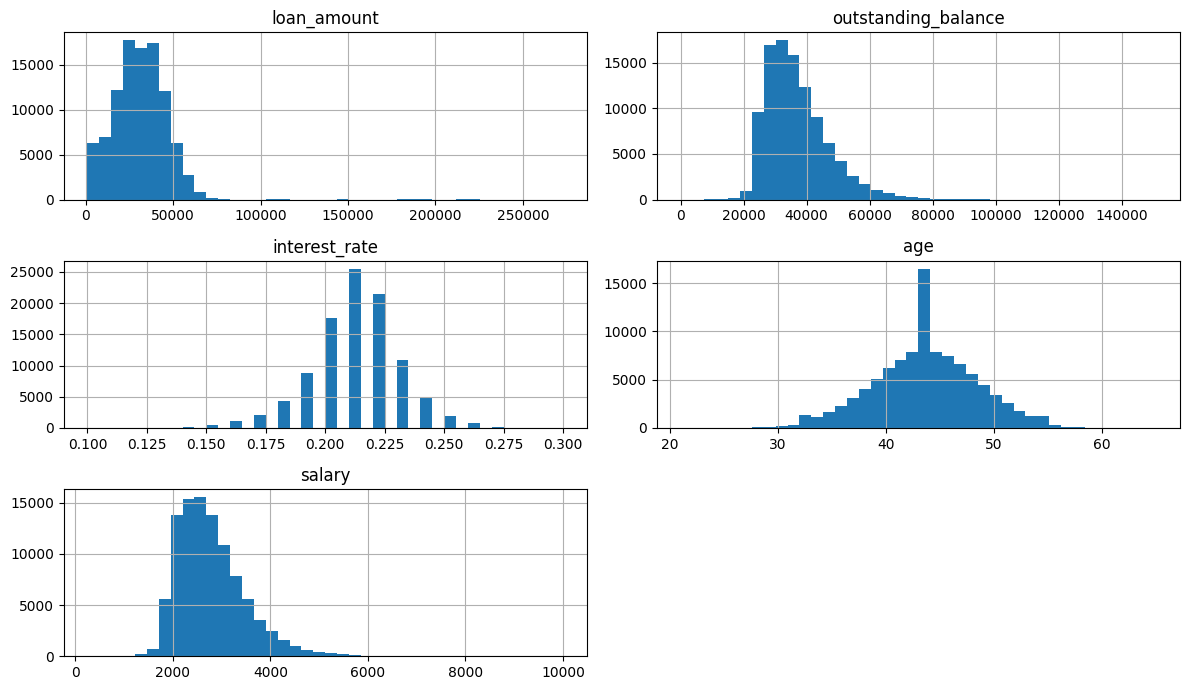

In [9]:
import matplotlib.pyplot as plt
raw[num].hist(bins=40, figsize=(12,7)); plt.tight_layout();